# Phase 2 - 3D Statistical Analysis

## Name: AYUSH KUMAR YADAV
## Registration Number: 23BDS0333
## Dataset: Lithium-Ion Battery Materials

### Objective

The objective of this notebook is to perform three-dimensional statistical
analysis on the Lithium-Ion Battery Materials dataset.

Three numerical variables are analyzed simultaneously to identify
relationships and patterns among material properties.

The analysis includes three-dimensional scatter plots, covariance and
correlation analysis, grouped statistical summaries, and comparisons
between crystal systems and bandstructure availability.

3D STATISTICAL ANALYSIS

Dataset Shape:
(339, 30)

Three-dimensional variables:
['formation_energy_ev', 'band_gap_ev', 'density_gm_cc']

STATISTICAL SUMMARY OF 3D VARIABLES


,formation_energy_ev,band_gap_ev,density_gm_cc
count,339.000000,339.000000,339.000000
mean,-2.616950,2.083417,2.984003
std,0.183809,1.087292,0.353968
min,-2.985000,0.000000,2.200000
25%,-2.757500,1.266500,2.760500
50%,-2.605000,2.505500,2.947000
75%,-2.525500,2.968000,3.106000
max,-2.012000,3.823000,4.201000



COVARIANCE MATRIX


,formation_energy_ev,band_gap_ev,density_gm_cc
formation_energy_ev,0.033786,-0.087470,0.031559
band_gap_ev,-0.087470,1.182205,-0.134458
density_gm_cc,0.031559,-0.134458,0.125294



PEARSON CORRELATION MATRIX


,formation_energy_ev,band_gap_ev,density_gm_cc
formation_energy_ev,1.000000,-0.437669,0.485055
band_gap_ev,-0.437669,1.000000,-0.349362
density_gm_cc,0.485055,-0.349362,1.000000


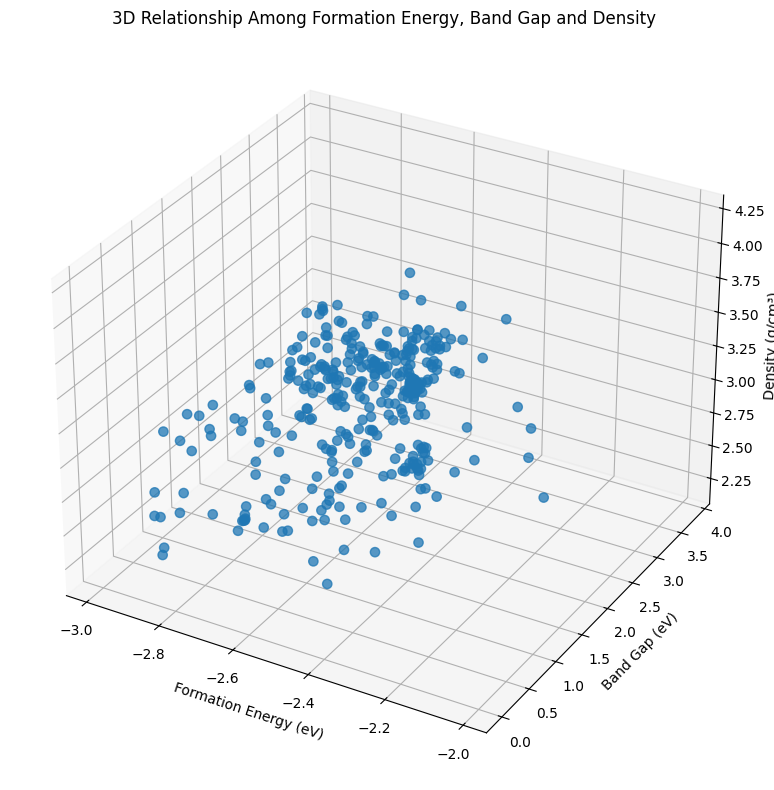

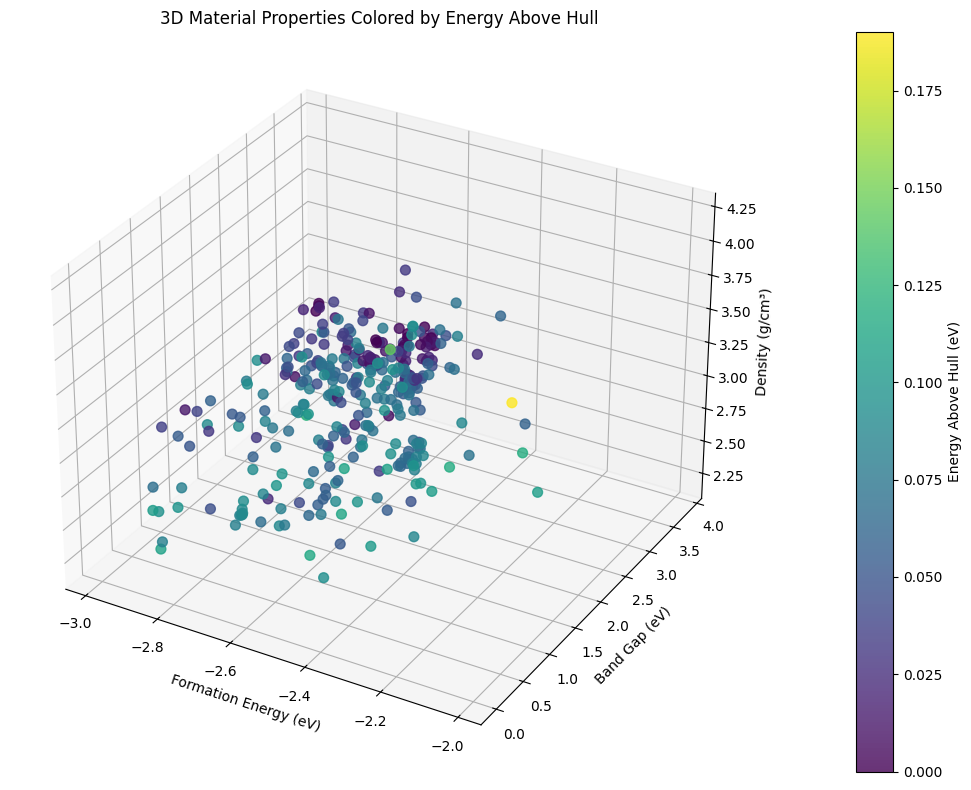

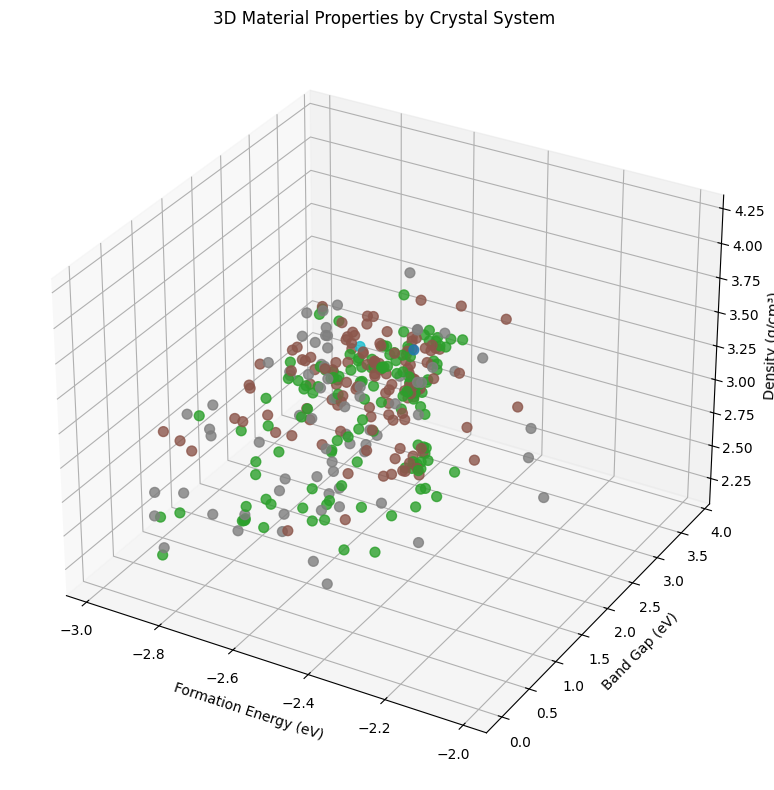


Crystal System Encoding:


,Code,Crystal System
0,0,?
1,1,Monoclinic
2,2,Orthorhombic
3,3,Triclinic
4,4,Unknown


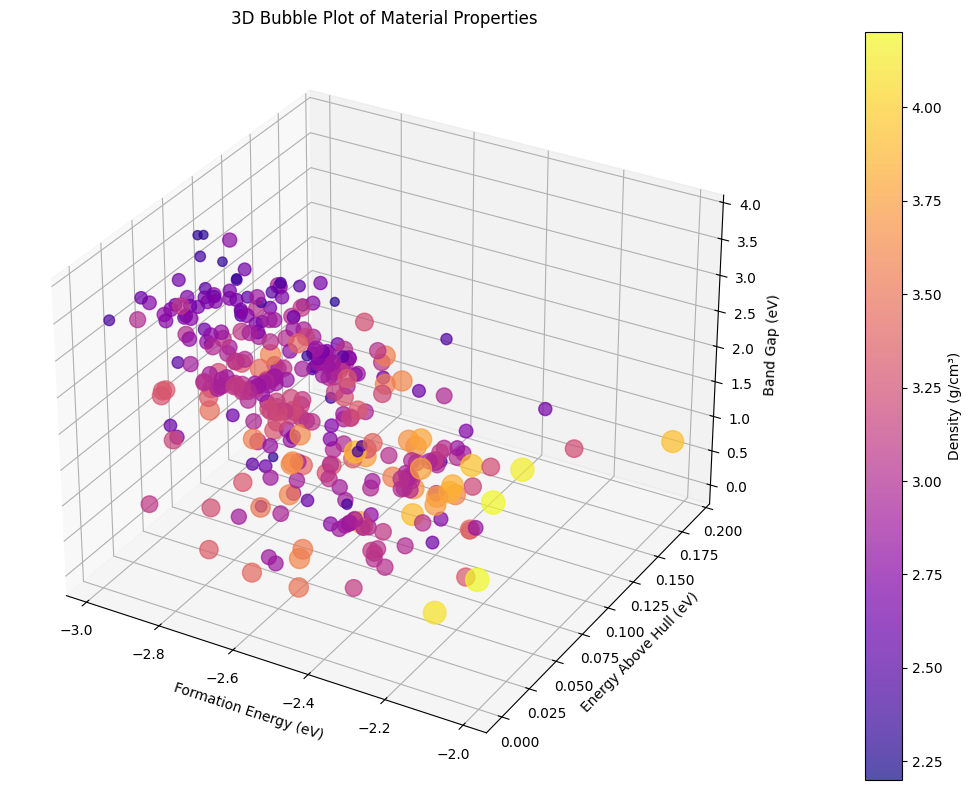


GROUPED SUMMARY BY CRYSTAL SYSTEM


formation_energy_ev                band_gap_ev                  \
                              mean median     std        mean  median     std   
crystal_system                                                                  
?                          -2.4090 -2.409     NaN      1.6580  1.6580     NaN   
Monoclinic                 -2.6159 -2.604  0.1675      2.1374  2.5870  1.1013   
Orthorhombic               -2.6165 -2.603  0.1802      2.2884  2.7370  0.9485   
Triclinic                  -2.6205 -2.626  0.2193      1.6071  1.8525  1.1684   
Unknown                    -2.7780 -2.778     NaN      3.1690  3.1690     NaN   

               density_gm_cc                  
                        mean  median     std  
crystal_system                                
?                     3.6920  3.6920     NaN  
Monoclinic            2.9127  2.8950  0.2999  
Orthorhombic          3.0373  2.9855  0.3691  
Triclinic             3.0161  2.9765  0.3968  
Unknown               2.9200  2.9200     NaN


SUMMARY BY BANDSTRUCTURE AVAILABILITY


formation_energy_ev                band_gap_ev          \
                                 mean median     std        mean  median   
has_bandstructure                                                          
False                         -2.6916 -2.721  0.2086      2.0509  2.5280   
True                          -2.5992 -2.598  0.1732      2.0911  2.4815   

                          density_gm_cc                  
                      std          mean  median     std  
has_bandstructure                                        
False              1.2783        2.8473  2.8070  0.3641  
True               1.0394        3.0164  2.9695  0.3443


THREE-WAY CORRELATION


,formation_energy_ev,band_gap_ev,density_gm_cc
formation_energy_ev,1.000000,-0.437669,0.485055
band_gap_ev,-0.437669,1.000000,-0.349362
density_gm_cc,0.485055,-0.349362,1.000000



DATA QUALITY CHECK
Missing values in selected variables: 0
Duplicate rows: 0

Number of observations used:
339

3D STATISTICAL ANALYSIS COMPLETED


In [1]:
# ============================================================
# PHASE 2 - 3D STATISTICAL ANALYSIS
# Name        : AYUSH KUMAR YADAV
# Registration: 23BDS0333
# Dataset     : Lithium-Ion Battery Materials
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "lithium_ion_transformed.csv"

df = pd.read_csv(file_path)

print("=" * 75)
print("3D STATISTICAL ANALYSIS")
print("=" * 75)

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 2. SELECT VARIABLES
# ------------------------------------------------------------

three_variables = [
    "formation_energy_ev",
    "band_gap_ev",
    "density_gm_cc"
]

three_variables = [
    column for column in three_variables
    if column in df.columns
]

print("\nThree-dimensional variables:")
print(three_variables)

# ------------------------------------------------------------
# 3. STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STATISTICAL SUMMARY OF 3D VARIABLES")
print("=" * 75)

display(
    df[three_variables].describe()
)

# ------------------------------------------------------------
# 4. COVARIANCE MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("COVARIANCE MATRIX")
print("=" * 75)

covariance_matrix = df[three_variables].cov()

display(covariance_matrix)

# ------------------------------------------------------------
# 5. PEARSON CORRELATION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PEARSON CORRELATION MATRIX")
print("=" * 75)

correlation_matrix = df[three_variables].corr()

display(correlation_matrix)

# ============================================================
# VISUALIZATION 1
# BASIC 3D SCATTER PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["formation_energy_ev"],
    df["band_gap_ev"],
    df["density_gm_cc"],
    s=45,
    alpha=0.75
)

ax.set_title(
    "3D Relationship Among Formation Energy, Band Gap and Density"
)

ax.set_xlabel("Formation Energy (eV)")
ax.set_ylabel("Band Gap (eV)")
ax.set_zlabel("Density (g/cm³)")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2
# 3D SCATTER COLORED BY ENERGY ABOVE HULL
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df["formation_energy_ev"],
    df["band_gap_ev"],
    df["density_gm_cc"],
    c=df["e_above_hull_ev"],
    cmap="viridis",
    s=50,
    alpha=0.8
)

ax.set_title(
    "3D Material Properties Colored by Energy Above Hull"
)

ax.set_xlabel("Formation Energy (eV)")
ax.set_ylabel("Band Gap (eV)")
ax.set_zlabel("Density (g/cm³)")

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.1
)

colorbar.set_label(
    "Energy Above Hull (eV)"
)

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 3
# 3D SCATTER COLORED BY CRYSTAL SYSTEM
# ============================================================

if "crystal_system" in df.columns:

    fig = plt.figure(figsize=(12, 8))

    ax = fig.add_subplot(111, projection="3d")

    crystal_codes = pd.Categorical(
        df["crystal_system"]
    ).codes

    scatter = ax.scatter(
        df["formation_energy_ev"],
        df["band_gap_ev"],
        df["density_gm_cc"],
        c=crystal_codes,
        cmap="tab10",
        s=50,
        alpha=0.8
    )

    ax.set_title(
        "3D Material Properties by Crystal System"
    )

    ax.set_xlabel("Formation Energy (eV)")
    ax.set_ylabel("Band Gap (eV)")
    ax.set_zlabel("Density (g/cm³)")

    plt.tight_layout()
    plt.show()

    print("\nCrystal System Encoding:")

    crystal_mapping = pd.DataFrame({
        "Code": range(
            len(
                pd.Categorical(
                    df["crystal_system"]
                ).categories
            )
        ),
        "Crystal System":
            pd.Categorical(
                df["crystal_system"]
            ).categories
    })

    display(crystal_mapping)

# ============================================================
# VISUALIZATION 4
# 3D BUBBLE PLOT
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(111, projection="3d")

# Normalize density for bubble size
density_min = df["density_gm_cc"].min()
density_max = df["density_gm_cc"].max()

if density_max != density_min:

    bubble_size = (
        (df["density_gm_cc"] - density_min)
        / (density_max - density_min)
        * 250
        + 30
    )

else:

    bubble_size = 50

scatter = ax.scatter(
    df["formation_energy_ev"],
    df["e_above_hull_ev"],
    df["band_gap_ev"],
    s=bubble_size,
    c=df["density_gm_cc"],
    cmap="plasma",
    alpha=0.7
)

ax.set_title(
    "3D Bubble Plot of Material Properties"
)

ax.set_xlabel("Formation Energy (eV)")
ax.set_ylabel("Energy Above Hull (eV)")
ax.set_zlabel("Band Gap (eV)")

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.1
)

colorbar.set_label(
    "Density (g/cm³)"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. GROUPED 3D STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("GROUPED SUMMARY BY CRYSTAL SYSTEM")
print("=" * 75)

if "crystal_system" in df.columns:

    grouped_summary = (
        df.groupby("crystal_system")[
            three_variables
        ]
        .agg(["mean", "median", "std"])
        .round(4)
    )

    display(grouped_summary)

# ------------------------------------------------------------
# 7. SUMMARY BY BANDSTRUCTURE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SUMMARY BY BANDSTRUCTURE AVAILABILITY")
print("=" * 75)

if "has_bandstructure" in df.columns:

    bandstructure_summary = (
        df.groupby("has_bandstructure")[
            three_variables
        ]
        .agg(["mean", "median", "std"])
        .round(4)
    )

    display(bandstructure_summary)

# ------------------------------------------------------------
# 8. THREE-WAY CORRELATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("THREE-WAY CORRELATION")
print("=" * 75)

display(
    df[three_variables].corr()
)

# ------------------------------------------------------------
# 9. CHECK FOR MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATA QUALITY CHECK")
print("=" * 75)

print(
    "Missing values in selected variables:",
    df[three_variables].isnull().sum().sum()
)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

# ------------------------------------------------------------
# 10. VERIFY NUMBER OF OBSERVATIONS
# ------------------------------------------------------------

print("\nNumber of observations used:")
print(len(df))

print("\n" + "=" * 75)
print("3D STATISTICAL ANALYSIS COMPLETED")
print("=" * 75)

# Conclusion

Three-dimensional statistical analysis was successfully performed on the
Lithium-Ion Battery Materials dataset.

The relationships among formation energy, band gap, density, and energy
above hull were examined simultaneously using three-dimensional scatter
plots and bubble visualization.

The analysis also examined how material properties vary across different
crystal systems and bandstructure availability using grouped statistical
summaries.

Covariance and correlation matrices were calculated to quantify relationships
among the selected three-dimensional variables.

The analysis provides a multidimensional view of the material properties and
prepares the dataset for clustering techniques in the next phase.